In [142]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import os
RESULTS_DIR = os.getcwd() + "/../results/H/safe_risky4/"
RESULTS_DIR

'/Users/angel/Desktop/prism-games/prism-examples/csgs/learning/analysis/../results/H/safe_risky4/'

In [171]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "axes.labelsize": 10,
    "font.size": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

In [197]:
fpath = Path(RESULTS_DIR) / "cleaned.csv"
print(fpath)
res_df = pd.read_csv(fpath)

/Users/angel/Desktop/prism-games/prism-examples/csgs/learning/analysis/../results/H/safe_risky4/cleaned.csv


In [198]:
# --- Basic cleaning ---
res_df = res_df.rename(columns={
    "time_mean (s)": "time",
    "time_std (s)": "time_std",
    "episodes_mean": "episodes"
})

cols = ["H", "episodes", "episodes_std", "time", "time_std", "samples_mean", "samples_std"]
res_df = res_df.loc[:, cols]
res_df = res_df.sort_values("H")
for c in cols:
    res_df[c] = pd.to_numeric(res_df[c], errors="coerce")
res_df = res_df[res_df['H'] < 11]

res_df = (
    res_df.replace(["#DIV/0!", ""], np.nan)  # Excel errors + empty strings
      .replace(r'^\s*$', np.nan, regex=True)  # whitespace
      .fillna(0)
)
res_df

,H,episodes,episodes_std,time,time_std,samples_mean,samples_std
0,1,4.436667e+02,4.041452,0.369403,0.036226,2.159900e+04,1456.654729
1,3,1.228247e+05,48.757905,176.401053,49.702453,1.161727e+07,8102.514754
2,5,4.597233e+05,309.892454,872.953995,7.821159,5.002537e+07,118976.881900
3,7,1.034418e+06,329.061291,3306.238060,85.729876,1.374247e+08,215975.960200
4,9,1.801268e+06,834.248364,9079.158604,355.373009,2.952176e+08,300366.386700


## Data cleaning only

In [137]:
H_LOGS_DIR = os.getcwd() + "/../logs/H/safe_risky4/run2-7"

Hs = [1, 3, 5, 7, 9]
total_samples = []

for H in Hs:
    df = pd.read_csv(Path(H_LOGS_DIR) / f"safe_risky4_{H}.csv")    
    df["numSamples"] = pd.to_numeric(df["numSamples"], errors="coerce").fillna(0)

    # total episodes from summary df
    final_episodes = res_df.loc[res_df["H"] == H, "episodes"].values[0]

    # split last row
    last_row = df.iloc[-1]
    last_episode_logged = last_row["episode"]
    last_numSamples = last_row["numSamples"]

    # sum all except last row
    total = (10 * df.iloc[:-1]["numSamples"]).sum()

    # add corrected last row contribution
    remaining_episodes = final_episodes - last_episode_logged + 1
    total += remaining_episodes * 10 * last_numSamples

    total_samples.append(total)

Hs = np.array(Hs)
total_samples = np.array(total_samples)

In [138]:
total_samples

array([2.2440000e+04, 1.1624920e+07, 5.0346330e+07, 1.3765034e+08,
       2.9487930e+08])

In [136]:
res_df['total_samples'] = total_samples
res_df

,H,episodes,episodes_std,time,time_std,total_samples
0,1,445.5,3.535534,0.381964,0.066807,22440.0
1,3,122797.0,12.727922,205.079591,10.814103,11608780.0
2,5,459755.0,431.335136,1481.368033,55.843574,49888280.0
3,7,1034522.0,388.908730,3208.278334,79.793286,137219890.0
4,9,1800539.0,0.000000,8871.236556,112.138072,295320470.0


# Complexity plots

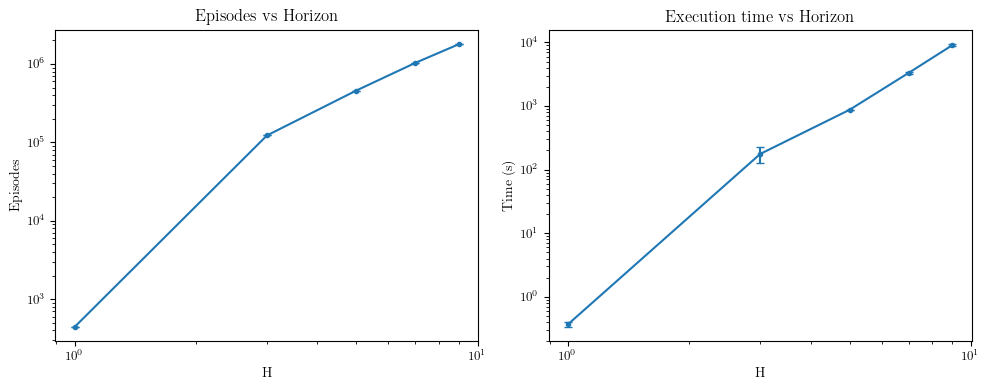

Saved plot to /Users/angel/Desktop/prism-games/prism-examples/csgs/learning/analysis/../results/H/safe_risky4/safe_risky_H_complexity.pdf


In [199]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# --- Episodes vs H ---
axes[0].errorbar(res_df["H"], res_df["episodes"], yerr=res_df["episodes_std"], 
                 marker='o', markersize=3, capsize=3)
axes[0].set_xlabel("H")
axes[0].set_ylabel("Episodes")
axes[0].set_title("Episodes vs Horizon")
axes[0].set_xscale("log")
axes[0].set_yscale("log")


# --- Time & Samples vs H ---
ax1 = axes[1]

# Time (left axis)
ax1.errorbar(res_df["H"], res_df["time"], yerr=res_df["time_std"], 
             marker='o', markersize=3, capsize=3, label="Time (s)")
             # , color="tab:blue")
ax1.set_xlabel("H")
ax1.set_ylabel("Time (s)") #, color="tab:blue")
ax1.tick_params(axis='y') # , labelcolor="tab:blue")
ax1.set_title("Execution time vs Horizon")

# Samples (right axis)
# ax2 = ax1.twinx()
# ax2.errorbar(res_df["H"], res_df["samples_mean"], yerr=res_df["samples_std"], 
#              marker='s', markersize=3, capsize=3, label="Samples", color="tab:orange")
# ax2.set_ylabel("Total samples", color="tab:orange")
# ax2.tick_params(axis='y', labelcolor="tab:orange")

# Combine legends
# lines_1, labels_1 = ax1.get_legend_handles_labels()
# lines_2, labels_2 = ax2.get_legend_handles_labels()
# ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")

axes[1].set_xscale("log")
axes[1].set_yscale("log")

plt.tight_layout()

# --- Save ---
output_path = Path(RESULTS_DIR) / "safe_risky_H_complexity.pdf"
plt.savefig(output_path)

plt.show()
plt.close()

print(f"Saved plot to {output_path}")

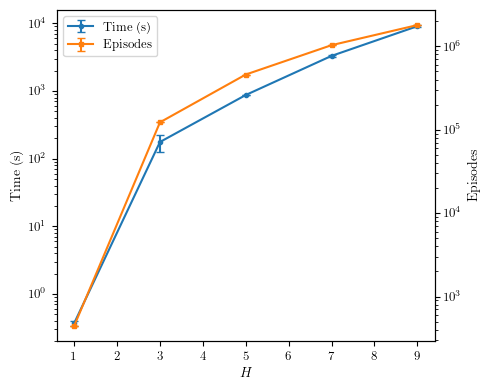

Saved plot to /Users/angel/Desktop/prism-games/prism-examples/csgs/learning/analysis/../results/H/safe_risky4/safe_risky4_H_complexity.pdf


In [201]:
fig, ax1 = plt.subplots(figsize=(5, 4))

# --- Time (left axis) ---
ax1.errorbar(res_df["H"], res_df["time"], yerr=res_df["time_std"], 
             marker='o', markersize=3, capsize=3, label="Time (s)")
ax1.set_xlabel(r"$H$")
ax1.set_ylabel("Time (s)")
# ax1.set_title("Execution Time & Episodes vs Horizon")

# --- Episodes (right axis) ---
ax2 = ax1.twinx()
ax2.errorbar(res_df["H"], res_df["episodes"], yerr=res_df["episodes_std"], 
             marker='s', markersize=3, capsize=3, label="Episodes", color="tab:orange")
ax2.set_ylabel("Episodes")

# --- Log scales ---
# ax1.set_xscale("log")
ax1.set_yscale("log")
ax2.set_yscale("log")

# --- Combine legends ---
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")

plt.tight_layout()

# --- Save ---
output_path = Path(RESULTS_DIR) / "safe_risky4_H_complexity.pdf"
plt.savefig(output_path)

plt.show()
plt.close()

print(f"Saved plot to {output_path}")

- episode vs. H: polynomial + constants might dominate for small H
- execution time vs. H: looks more expensive
  - number of samples increase per episode (each of length H) -> per-episode cost $\approx H\cdot N^\omega_t$

## Complexity in $\varepsilon$

In [187]:
LOGS_DIR = os.getcwd() + "/../logs/H/safe_risky4/run3-299/"
LOGS_DIR

'/Users/angel/Desktop/prism-games/prism-examples/csgs/learning/analysis/../logs/H/safe_risky4/run3-299/'

In [188]:
log_df = pd.read_csv(Path(LOGS_DIR) / "safe_risky4_3.csv")
log_df

,episode,deltaT,maxRadius,avgRadius,numUnknownSlots,propUnknown,numSamples,totalNumSamples
0,1,9.000000,2.000000,1.722262,16,1.00,51,51
1,11,4.247555,0.874510,0.503646,16,1.00,120,1077
2,21,2.721755,0.587013,0.356307,16,1.00,135,2369
3,31,2.227994,0.488238,0.289682,16,1.00,144,3773
4,41,1.874671,0.407235,0.249499,16,1.00,151,5252
...,...,...,...,...,...,...,...,...
12283,122831,0.050009,0.011113,0.006957,4,0.25,77,11614333
12284,122841,0.050007,0.011113,0.006956,4,0.25,77,11615103
12285,122851,0.050006,0.011112,0.006956,4,0.25,77,11615873
12286,122861,0.050004,0.011112,0.006956,4,0.25,77,11616643


In [189]:
log_df["numSamples"] = pd.to_numeric(log_df["numSamples"], errors="coerce").fillna(0)
log_df["deltaT"] = pd.to_numeric(log_df["deltaT"], errors="coerce").fillna(0)
# --- Compute epsilon ---
log_df["epsilon"] = log_df["deltaT"] / 4.0
# --- Compute cumulative samples ---
if "totalNumSamples" in log_df.columns:
    log_df["cumSamples"] = pd.to_numeric(log_df["totalNumSamples"], errors="coerce").fillna(0)
else:
    log_df["cumSamples"] = log_df["numSamples"].cumsum()

log_df = log_df.sort_values("epsilon")

In [190]:
log_df

,episode,deltaT,maxRadius,avgRadius,numUnknownSlots,propUnknown,numSamples,totalNumSamples,epsilon,cumSamples
12287,122871,0.050002,0.011112,0.006956,4,0.25,77,11617413,0.012501,11617413
12286,122861,0.050004,0.011112,0.006956,4,0.25,77,11616643,0.012501,11616643
12285,122851,0.050006,0.011112,0.006956,4,0.25,77,11615873,0.012501,11615873
12284,122841,0.050007,0.011113,0.006956,4,0.25,77,11615103,0.012502,11615103
12283,122831,0.050009,0.011113,0.006957,4,0.25,77,11614333,0.012502,11614333
...,...,...,...,...,...,...,...,...,...,...
4,41,1.874671,0.407235,0.249499,16,1.00,151,5252,0.468668,5252
3,31,2.227994,0.488238,0.289682,16,1.00,144,3773,0.556998,3773
2,21,2.721755,0.587013,0.356307,16,1.00,135,2369,0.680439,2369
1,11,4.247555,0.874510,0.503646,16,1.00,120,1077,1.061889,1077


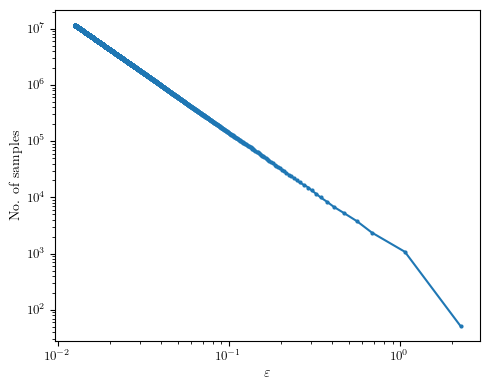

In [191]:
plt.figure(figsize=(5, 4))
plt.plot(log_df["epsilon"], log_df["cumSamples"], marker='o', markersize=2)

plt.xlabel(r"$\varepsilon$")
plt.ylabel("No. of samples")
# plt.title("Sample complexity vs ε")

plt.xscale("log")
plt.yscale("log")

plt.tight_layout()

output_path = Path(RESULTS_DIR) / "safe_risky4_3_eps_complexity.pdf"
plt.savefig(output_path)

plt.show()
plt.close()